In [2]:
# from huggingface_hub import notebook_login
# notebook_login()


In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from datasets import load_dataset
import matplotlib.pyplot as plt


splits = {'train': 'train.csv', 'validation': 'dev.csv', 'test': 'test.csv'}

train_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["train"])
drop_idx = train_df[train_df["label_id"] == 0].index[2000:]
train_df = train_df.drop(drop_idx)
train_df = train_df.reset_index()

test_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["validation"])

train_df

,index,free_text,label_id
0,0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0
...,...,...,...
6157,24013,"Công nghệ của cs đã đạt mức thượng thừa rồi, c...",2
6158,24016,Corona ăn mất cái ý thức của chị rồi hả chị ơi :),2
6159,24027,Đéo thấy thằng nào bị tử hình... vì các nghìn ...,1
6160,24029,Mất hình tượng vl,1


# EDA

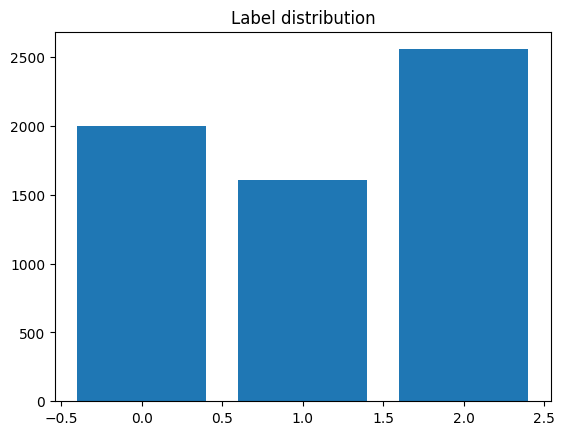

In [4]:
labels = [0, 1, 2]
label_cnt = [train_df[train_df["label_id"] == labels[i]].shape[0] for i in labels]

plt.title("Label distribution")
plt.bar(labels, label_cnt)
plt.show()

In [5]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len
        self.tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.tokenizer(str(self.texts[idx]), padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        label = self.labels[idx]
        label = torch.tensor(label, dtype=torch.long)

        
        return{
            'input_ids': tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
            'labels': label
        }

BATCH_SIZE = 64
train_ds = ToxicDataset(train_df["free_text"], train_df["label_id"])
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True, num_workers=4, pin_memory=True)
test_ds = ToxicDataset(test_df["free_text"], test_df["label_id"])
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False, num_workers=4, pin_memory=True)

for batch_idx, batch_data in enumerate(train_loader):
    # i is the batch index (0, 1, 2, ...)
    # inputs is the batch of features
    # targets is the batch of labels
    
    print(f"Batch {batch_idx} loaded with input shape: {batch_data["input_ids"].shape}")
    break



class ToxicClassifier(nn.Module):
    def __init__(self, hidden_size=512):
        super().__init__()
        self.pho_bert = AutoModel.from_pretrained("vinai/phobert-base")
        
        for param in self.pho_bert.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Linear(768, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 256),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, inp, atn_msk):
        x = self.pho_bert(input_ids=inp, attention_mask=atn_msk)
        x = self.classifier(x.last_hidden_state[:, 0, :])
        return x



config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batch 0 loaded with input shape: torch.Size([64, 256])


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

model = ToxicClassifier()


EPOCHS = 5
LR = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(DEVICE)

best_f1 = 0
for epoch in range(EPOCHS):
    model.train()

    train_total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training:")
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(inp=input_ids, atn_msk=attention_mask)
        
        loss = criterion(logits.view(-1, 3), labels.view(-1))
        loss.backward()
        optimizer.step()

        train_total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    val_total_loss = 0
    val_correct_cnt = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating: "):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits = model(inp=input_ids, atn_msk=attention_mask)
            preds = torch.argmax(logits.view(-1, 3), dim = -1)
            val_correct_cnt += (preds == labels).sum().item()

            val_total_loss += criterion(logits.view(-1, 3), labels.view(-1))

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            
    val_accuracy = val_correct_cnt / len(test_df)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    
    print(f"EPOCHS {epoch+1}: Train Loss = {train_total_loss / len(train_df) :.4f}  ;  Val Loss = {val_total_loss / len(test_df) :.4f}  ; Val Acc = {val_accuracy}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model!")
